# Clustering Exploration

This notebook supports the final presentation by following the slide-13 analysis framework exactly: parse Snow Pilot CAAML files, create slabs from each layer of concern, engineer slab, weak-layer, and Extended Column Test (ECT) variables, then compare fixed K=2 K-means results across the presentation feature sets.

The analysis asks whether any feature set produces compact two-cluster structure and concentrates pits marked as near an avalanche in one post-clustering group. Near-avalanche pits are treated as known unstable examples. Pits without that flag are treated as unlabeled or unknown context, not stable negatives.

Avalanche context is never used as a clustering input. It is used only after clustering to describe the near-avalanche enriched cluster. Results are therefore exploratory feature-set diagnostics, not a validated operational stability classifier.

## Setup

Imports, paths, model settings, presentation feature-set definitions, and display labels live here so the rest of the notebook reads like the analysis framework in the presentation. The primary comparison sets are the five slide-13 feature families: slab features, weak-layer features, slab plus weak-layer features, ECT results, and slab/weak-layer/ECT results.

In [1]:
import re
import sys
import warnings
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR
    NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

SNOWPYT_MECHPARAMS_SRC = PROJECT_ROOT.parent / "SnowPyt-MechParams" / "src"
for import_path in [NOTEBOOK_DIR, SNOWPYT_MECHPARAMS_SRC]:
    import_path_text = str(import_path)
    if import_path.exists() and import_path_text not in sys.path:
        sys.path.insert(0, import_path_text)

from caaml_utils import parse_caaml_directory
from snowpyt_mechparams.execution import ExecutionEngine
from snowpyt_mechparams.models import Pit

try:
    from tqdm.auto import tqdm
except ImportError:

    def tqdm(items, **_kwargs):
        return items

warnings.filterwarnings(
    "ignore",
    message="Using UFloat objects with std_dev==0 may give unexpected results.",
)

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = PROJECT_ROOT / "snowpits" / "2015_2025"
RANDOM_STATE = 42
KMEANS_N_CLUSTERS = 2
ECT_MAX_TAPS = 31.0
CLUSTER_ORDER_COLUMN = "slab_weight_N_m2"
PERMUTATION_N_ITERATIONS = 1000
BOOTSTRAP_N_ITERATIONS = 1000

ANALYSIS_METADATA_COLUMNS = [
    "pit_id",
    "slab_id",
    "near_avalanche_flag",
    "near_avalanche_raw",
    "near_avalanche_status",
]

FEATURE_SET_DEFINITIONS = {
    "slab_features": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "bending_stiffness_D11_N_mm",
    ],
    "weak_layer_features": [
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
    ],
    "slab_plus_weak_layer_features": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "bending_stiffness_D11_N_mm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
    ],
    "ect_results": [
        "ect_propagation_rate",
        "ect_mean_taps",
        "ect_instability_index",
        "ect_has_propagating_result",
    ],
    "slab_weak_layer_ect_results": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "bending_stiffness_D11_N_mm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
        "ect_propagation_rate",
        "ect_mean_taps",
        "ect_instability_index",
        "ect_has_propagating_result",
    ],
}
FEATURE_SET_NAMES = list(FEATURE_SET_DEFINITIONS)

FORBIDDEN_CLUSTERING_FEATURE_COLUMNS = set(ANALYSIS_METADATA_COLUMNS) | {
    "near_avalanche",
    "near_avalanche_label",
    "pit_date",
    "season",
    "month",
    "operation_name",
    "country",
    "region",
    "elevation",
    "slope_angle",
    "aspect",
}

COVERAGE_FEATURE_COLUMNS = [
    "slab_thickness_cm",
    "slab_weight_N_m2",
    "n_layers",
    "cumulative_hhi_cm",
    "slab_mean_hhi",
    "bending_stiffness_D11_N_mm",
    "weak_layer_thickness_cm",
    "weak_layer_hhi",
    "weak_layer_persistent_grain",
    "ect_propagation_rate",
    "ect_mean_taps",
    "ect_instability_index",
    "ect_has_propagating_result",
    "ect_mean_propagating_taps",
    "ect_count",
    "ect_parsed_count",
]
FEATURE_DISPLAY_NAMES = {
    "slab_thickness_cm": "Slab thickness (cm)",
    "slab_weight_N_m2": "Slab weight (N/m2)",
    "n_layers": "Slab layer count",
    "cumulative_hhi_cm": "Cumulative slab HHI (cm)",
    "slab_mean_hhi": "Mean slab HHI",
    "bending_stiffness_D11_N_mm": "Bending stiffness D11 (N mm)",
    "weak_layer_thickness_cm": "Weak-layer thickness (cm)",
    "weak_layer_hhi": "Weak-layer HHI",
    "weak_layer_persistent_grain": "Weak-layer persistent grain flag",
    "ect_propagation_rate": "ECT propagation rate",
    "ect_mean_taps": "ECT mean taps",
    "ect_instability_index": "ECT instability index",
    "ect_has_propagating_result": "ECT has propagating result",
    "ect_mean_propagating_taps": "ECT mean propagating taps",
    "ect_count": "ECT count",
    "ect_parsed_count": "Parsed ECT count",
}
FEATURE_SET_DISPLAY_NAMES = {
    "slab_features": "Slab features",
    "weak_layer_features": "Weak-layer features",
    "slab_plus_weak_layer_features": "Slab + weak-layer features",
    "ect_results": "ECT results",
    "slab_weak_layer_ect_results": "Slab + weak-layer + ECT results",
}

WEIGHT_METHODS = {
    "density": "kim_jamieson_table2",
    "slab_weight": "sum_layer_weight",
}
D11_METHODS = {
    "density": "kim_jamieson_table2",
    "elastic_modulus": "schottner",
    "poissons_ratio": "kochle",
    "D11": "weissgraeber_rosendahl",
}

pd.options.display.float_format = "{:,.3f}".format

## Helper Functions

These helpers keep the analysis cells short. They handle uncertain values, missing values, avalanche-context labels, slab-level hand-hardness summaries, ECT score parsing, K-means enrichment diagnostics, permutation checks, and bootstrap intervals.

In [2]:
def nominal_value(value):
    """Return a finite float from a scalar, unit tuple/list, or uncertainties value."""
    if value is None:
        return np.nan
    if isinstance(value, (list, tuple)):
        if not value:
            return np.nan
        value = value[0]
    value = getattr(value, "nominal_value", value)
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value if np.isfinite(value) else np.nan


def near_avalanche_status_from_raw(value):
    """Keep true, false, and missing avalanche context distinct."""
    if value is True:
        return "Near avalanche"
    if value is False:
        return "Explicitly not near avalanche"
    return "Unknown/not recorded"


def cumulative_hhi_cm(slab):
    """Sum layer hand hardness index multiplied by layer thickness in cm."""
    total = 0.0
    for layer in slab.layers:
        hhi = nominal_value(layer.hand_hardness_index)
        thickness = nominal_value(layer.thickness)
        if np.isnan(hhi) or np.isnan(thickness):
            return np.nan
        total += hhi * thickness
    return total


def slab_mean_hhi(slab):
    """Return thickness-weighted mean slab hand hardness index."""
    cumulative_hhi = cumulative_hhi_cm(slab)
    slab_thickness = nominal_value(slab.total_thickness)
    if np.isnan(cumulative_hhi) or np.isnan(slab_thickness) or slab_thickness <= 0:
        return np.nan
    return cumulative_hhi / slab_thickness


def weak_layer_persistent_grain_flag(weak_layer):
    """Flag depth hoar, facets, or surface hoar weak layers."""
    if weak_layer is None:
        return np.nan
    grain_form = getattr(weak_layer, "main_grain_form", None)
    if grain_form is None:
        raw_grain_form = getattr(weak_layer, "grain_form", None)
        grain_form = str(raw_grain_form)[:2] if raw_grain_form is not None else None
    if grain_form is None:
        return np.nan
    return float(str(grain_form).upper() in {"DH", "FC", "SH"})


def mean_or_nan(values):
    """Return the mean of finite values, or NaN when no finite values exist."""
    valid_values = [value for value in values if not np.isnan(value)]
    return float(np.mean(valid_values)) if valid_values else np.nan


def parse_ect_result(ect):
    """Parse one ECT result into propagation, tap count, depth, and instability score."""
    score = (getattr(ect, "test_score", None) or "").strip().upper()
    propagation = np.nan
    taps = np.nan
    depth_top = nominal_value(getattr(ect, "depth_top", None))

    # ECTPV is propagation during isolation. ECTX is treated as non-propagating
    # at the maximum score so tap-based summaries stay on the ECT 0-31 scale.
    if score == "ECTPV":
        propagation = 1.0
        taps = 0.0
    elif score == "ECTX":
        propagation = 0.0
        taps = ECT_MAX_TAPS
    elif score.startswith("ECT") and len(score) >= 4:
        propagation_code = score[3]
        if propagation_code == "P":
            propagation = 1.0
        elif propagation_code in {"N", "X"}:
            propagation = 0.0

        tap_match = re.search(r"\d+", score[4:] if len(score) > 4 else "")
        if tap_match:
            taps = float(tap_match.group(0))
    elif getattr(ect, "propagation", None) is not None:
        propagation = 1.0 if ect.propagation else 0.0

    if np.isnan(taps) and getattr(ect, "num_taps", None) is not None:
        tap_match = re.search(r"\d+", str(ect.num_taps))
        if tap_match:
            taps = float(tap_match.group(0))

    if np.isnan(propagation):
        instability = np.nan
    elif propagation == 0.0:
        instability = 0.0
    elif np.isnan(taps):
        instability = np.nan
    else:
        instability = float(np.clip((ECT_MAX_TAPS - taps) / ECT_MAX_TAPS, 0.0, 1.0))

    return {
        "score": score,
        "propagation": propagation,
        "taps": taps,
        "depth_top": depth_top,
        "instability": instability,
    }


def summarize_ect_results(ect_results):
    """Summarize all ECT results attached to a slab."""
    parsed_results = [parse_ect_result(ect) for ect in ect_results]
    propagation_values = [result["propagation"] for result in parsed_results]
    tap_values = [result["taps"] for result in parsed_results]
    depth_values = [result["depth_top"] for result in parsed_results]
    instability_values = [result["instability"] for result in parsed_results]
    propagating_taps = [
        result["taps"]
        for result in parsed_results
        if result["propagation"] == 1.0 and not np.isnan(result["taps"])
    ]
    parsed_count = sum(
        not np.isnan(result["propagation"]) or not np.isnan(result["taps"])
        for result in parsed_results
    )
    has_propagating_result = any(result["propagation"] == 1.0 for result in parsed_results)

    return {
        "ect_count": len(ect_results),
        "ect_parsed_count": parsed_count,
        "ect_propagation_rate": mean_or_nan(propagation_values),
        "ect_mean_taps": mean_or_nan(tap_values),
        "ect_instability_index": mean_or_nan(instability_values),
        "ect_has_propagating_result": (
            float(has_propagating_result) if parsed_count > 0 else np.nan
        ),
        "ect_mean_propagating_taps": mean_or_nan(propagating_taps),
        "ect_mean_depth_top_cm": mean_or_nan(depth_values),
        "has_ECT": len(ect_results) > 0,
        "has_ECT_features": parsed_count > 0,
        "has_ECT_propagating_tap_timing": len(propagating_taps) > 0,
    }


def between_cluster_rate_difference(
    clustered_df,
    label_column="near_avalanche_flag",
    cluster_column="cluster",
):
    """Return the absolute difference in near-avalanche rates between two clusters."""
    rates = clustered_df.groupby(cluster_column)[label_column].mean()
    if len(rates) < 2:
        return np.nan
    return float((rates.max() - rates.min()) * 100)


def permutation_rate_difference_p_value(clustered_df, cluster_column="cluster"):
    """Estimate whether the cluster rate difference exceeds random label assignment."""
    observed_difference = between_cluster_rate_difference(
        clustered_df,
        cluster_column=cluster_column,
    )
    if np.isnan(observed_difference):
        return np.nan

    labels = clustered_df["near_avalanche_flag"].astype(float).to_numpy()
    if labels.sum() == 0 or labels.sum() == len(labels):
        return np.nan

    rng = np.random.default_rng(RANDOM_STATE)
    cluster_ids = clustered_df[cluster_column].to_numpy()
    permuted_differences = []
    for _ in range(PERMUTATION_N_ITERATIONS):
        permuted_df = pd.DataFrame(
            {
                cluster_column: cluster_ids,
                "near_avalanche_flag": rng.permutation(labels),
            }
        )
        permuted_differences.append(
            between_cluster_rate_difference(
                permuted_df,
                cluster_column=cluster_column,
            )
        )

    return float(
        (np.sum(np.array(permuted_differences) >= observed_difference) + 1)
        / (PERMUTATION_N_ITERATIONS + 1)
    )


def bootstrap_enriched_cluster_intervals(
    clustered_df,
    enriched_cluster,
    n_iterations=BOOTSTRAP_N_ITERATIONS,
    random_state=RANDOM_STATE,
):
    """Bootstrap in-sample enrichment metrics with fixed cluster assignments."""
    empty_intervals = {
        "enriched_cluster_near_avalanche_rate_ci_low": np.nan,
        "enriched_cluster_near_avalanche_rate_ci_high": np.nan,
        "enriched_cluster_rate_lift_ci_low": np.nan,
        "enriched_cluster_rate_lift_ci_high": np.nan,
        "enriched_cluster_rate_minus_baseline_ci_low": np.nan,
        "enriched_cluster_rate_minus_baseline_ci_high": np.nan,
    }
    if clustered_df.empty:
        return empty_intervals

    labels = clustered_df["near_avalanche_flag"].astype(float).to_numpy()
    clusters = clustered_df["cluster"].to_numpy()
    n_rows = len(clustered_df)
    rng = np.random.default_rng(random_state)
    bootstrap_metrics = []

    for _ in range(n_iterations):
        sample_indices = rng.integers(0, n_rows, size=n_rows)
        sample_labels = labels[sample_indices]
        sample_clusters = clusters[sample_indices]
        enriched_labels = sample_labels[sample_clusters == enriched_cluster]
        if len(enriched_labels) == 0:
            continue

        baseline_rate = 100 * sample_labels.mean()
        enriched_rate = 100 * enriched_labels.mean()
        bootstrap_metrics.append(
            {
                "enriched_cluster_near_avalanche_rate": enriched_rate,
                "enriched_cluster_rate_lift": (
                    enriched_rate / baseline_rate if baseline_rate > 0 else np.nan
                ),
                "enriched_cluster_rate_minus_baseline": enriched_rate - baseline_rate,
            }
        )

    bootstrap_df = pd.DataFrame(bootstrap_metrics).dropna()
    if bootstrap_df.empty:
        return empty_intervals

    return {
        "enriched_cluster_near_avalanche_rate_ci_low": bootstrap_df[
            "enriched_cluster_near_avalanche_rate"
        ].quantile(0.025),
        "enriched_cluster_near_avalanche_rate_ci_high": bootstrap_df[
            "enriched_cluster_near_avalanche_rate"
        ].quantile(0.975),
        "enriched_cluster_rate_lift_ci_low": bootstrap_df[
            "enriched_cluster_rate_lift"
        ].quantile(0.025),
        "enriched_cluster_rate_lift_ci_high": bootstrap_df[
            "enriched_cluster_rate_lift"
        ].quantile(0.975),
        "enriched_cluster_rate_minus_baseline_ci_low": bootstrap_df[
            "enriched_cluster_rate_minus_baseline"
        ].quantile(0.025),
        "enriched_cluster_rate_minus_baseline_ci_high": bootstrap_df[
            "enriched_cluster_rate_minus_baseline"
        ].quantile(0.975),
    }

## Data Loading

Parse the CAAML files, then convert SnowPylot pits into SnowPyt-MechParams pit objects for slab creation and mechanical-property calculations.


In [3]:
raw_pits = parse_caaml_directory(DATA_DIR)
mech_pits = [Pit.from_snow_pit(pit) for pit in raw_pits]

loading_summary_df = pd.DataFrame(
    {
        "metric": ["CAAML directory", "Parsed SnowPylot pits", "Converted mech pits"],
        "value": [str(DATA_DIR), f"{len(raw_pits):,}", f"{len(mech_pits):,}"],
    }
)
loading_summary_df


,metric,value
0,CAAML directory,/Users/marykate/Desktop/Snow/snowpylot-applica...
1,Parsed SnowPylot pits,"50,278"
2,Converted mech pits,"50,278"


## Slab And Weak-Layer Feature Engineering

Each slab is created from the layer of concern. The feature table keeps identifiers, the original near-avalanche marker, an explicit avalanche-context status, slab load/structure features, core weak-layer features, and D11 for low-coverage sensitivity analysis.

In [4]:
slab_records = []

for raw_pit, mech_pit in zip(raw_pits, mech_pits):
    location = raw_pit.core_info.location
    near_avalanche_raw = location.pit_near_avalanche
    near_avalanche_status = near_avalanche_status_from_raw(near_avalanche_raw)
    ect_results = raw_pit.stability_tests.ECT if raw_pit.stability_tests else []

    for slab in mech_pit.create_slabs(weak_layer_def="layer_of_concern"):
        slab_records.append(
            {
                "pit_id": mech_pit.pit_id,
                "near_avalanche_flag": near_avalanche_raw is True,
                "near_avalanche_raw": near_avalanche_raw,
                "near_avalanche_status": near_avalanche_status,
                "slab": slab,
                "slab_layers": slab.layers,
                "snow_pit": raw_pit,
                "mech_pit": mech_pit,
                "ect_results": ect_results,
            }
        )

slab_status_counts_df = pd.Series(
    [record["near_avalanche_status"] for record in slab_records],
    name="near_avalanche_status",
).value_counts(dropna=False).rename_axis("near_avalanche_status").reset_index(name="slab_count")

slab_summary_df = pd.DataFrame(
    {
        "metric": ["Usable slabs", "Slabs marked near avalanche"],
        "value": [
            f"{len(slab_records):,}",
            f"{sum(record['near_avalanche_flag'] for record in slab_records):,}",
        ],
    }
)

display(slab_summary_df)
slab_status_counts_df


,metric,value
0,Usable slabs,"34,690"
1,Slabs marked near avalanche,"1,381"


,near_avalanche_status,slab_count
0,Unknown/not recorded,33309
1,Near avalanche,1381


In [5]:
engine = ExecutionEngine()
feature_records = []

for slab_record in tqdm(slab_records, desc="Creating slab features", unit="slab"):
    slab = slab_record["slab"]
    weak_layer = slab.weak_layer

    weight_result = engine.execute_single(slab, "slab_weight", WEIGHT_METHODS)
    slab_weight = (
        nominal_value(weight_result.slab.slab_weight)
        if weight_result is not None and weight_result.success
        else np.nan
    )

    d11_result = engine.execute_single(slab, "D11", D11_METHODS)
    bending_stiffness = (
        nominal_value(d11_result.slab.D11)
        if d11_result is not None and d11_result.success
        else np.nan
    )

    feature_records.append(
        {
            "pit_id": slab_record["pit_id"],
            "slab_id": slab.slab_id,
            "near_avalanche_flag": slab_record["near_avalanche_flag"],
            "near_avalanche_raw": slab_record["near_avalanche_raw"],
            "near_avalanche_status": slab_record["near_avalanche_status"],
            "n_layers": len(slab.layers),
            "slab_thickness_cm": nominal_value(slab.total_thickness),
            "slab_weight_N_m2": slab_weight,
            "bending_stiffness_D11_N_mm": bending_stiffness,
            "cumulative_hhi_cm": cumulative_hhi_cm(slab),
            "slab_mean_hhi": slab_mean_hhi(slab),
            "weak_layer_depth_top_cm": nominal_value(
                getattr(weak_layer, "depth_top", None)
            ),
            "weak_layer_thickness_cm": nominal_value(
                getattr(weak_layer, "thickness", None)
            ),
            "weak_layer_hhi": nominal_value(
                getattr(weak_layer, "hand_hardness_index", None)
            ),
            "weak_layer_persistent_grain": weak_layer_persistent_grain_flag(weak_layer),
        }
    )

slab_features_df = pd.DataFrame(feature_records)

feature_coverage_df = pd.DataFrame(
    {
        "feature": [
            column
            for column in COVERAGE_FEATURE_COLUMNS
            if column in slab_features_df.columns
        ],
    }
)
feature_coverage_df["display_name"] = feature_coverage_df["feature"].map(
    FEATURE_DISPLAY_NAMES
)
feature_coverage_df["non_null_count"] = [
    slab_features_df[column].notna().sum()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["coverage"] = [
    slab_features_df[column].notna().mean()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df


,feature,display_name,non_null_count,coverage
0,slab_thickness_cm,Slab thickness (cm),34690,1.000
1,slab_weight_N_m2,Slab weight (N/m2),14796,0.427
2,n_layers,Slab layer count,34690,1.000
3,cumulative_hhi_cm,Cumulative slab HHI (cm),25027,0.721
4,slab_mean_hhi,Mean slab HHI,25027,0.721
5,bending_stiffness_D11_N_mm,Bending stiffness D11 (N mm),1590,0.046
6,weak_layer_thickness_cm,Weak-layer thickness (cm),34690,1.000
7,weak_layer_hhi,Weak-layer HHI,31316,0.903
8,weak_layer_persistent_grain,Weak-layer persistent grain flag,31663,0.913


## ECT Features

ECT strings are converted into numerical summaries for the presentation's ECT-results feature set. Propagating tests with fewer taps receive a higher instability score; non-propagating tests receive zero. Rows with unparseable ECT data keep missing values and are filtered out only for feature sets that include ECT variables. The parser QA table below makes the score rules explicit before those features are used.

In [6]:
# Quick parser QA for common ECT encodings before applying the parser to the corpus.
ect_parser_examples = [
    SimpleNamespace(test_score="ECTPV", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTX", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTP12", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTN4", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTN25", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="bad score", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score=None, num_taps=None, depth_top=None),
]
ect_parser_qa_df = pd.DataFrame(
    [parse_ect_result(ect_example) for ect_example in ect_parser_examples]
)

ect_feature_records = [
    summarize_ect_results(slab_record["ect_results"])
    for slab_record in slab_records
]
ect_features_df = pd.DataFrame(ect_feature_records)

slab_features_df = pd.concat(
    [slab_features_df.reset_index(drop=True), ect_features_df],
    axis=1,
)

feature_coverage_df = pd.DataFrame(
    {
        "feature": [
            column
            for column in COVERAGE_FEATURE_COLUMNS
            if column in slab_features_df.columns
        ],
    }
)
feature_coverage_df["display_name"] = feature_coverage_df["feature"].map(
    FEATURE_DISPLAY_NAMES
)
feature_coverage_df["non_null_count"] = [
    slab_features_df[column].notna().sum()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["coverage"] = [
    slab_features_df[column].notna().mean()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["used_in_slide_13_feature_set"] = feature_coverage_df[
    "feature"
].isin(set().union(*FEATURE_SET_DEFINITIONS.values()))
feature_coverage_df["low_coverage_warning"] = feature_coverage_df["coverage"] < 0.50

ect_coverage_df = pd.DataFrame(
    {
        "metric": [
            "Slabs with ECT results",
            "Slabs with parsed ECT features",
            "Slabs with complete ECT clustering features",
            "Slabs with propagating ECT tap timing",
        ],
        "value": [
            int(slab_features_df["has_ECT"].sum()),
            int(slab_features_df["has_ECT_features"].sum()),
            int(
                slab_features_df[
                    FEATURE_SET_DEFINITIONS["ect_results"]
                ].notna().all(axis=1).sum()
            ),
            int(slab_features_df["has_ECT_propagating_tap_timing"].sum()),
        ],
    }
)

feature_set_definition_df = pd.DataFrame(
    [
        {
            "feature_set": feature_set_name,
            "display_name": FEATURE_SET_DISPLAY_NAMES[feature_set_name],
            "n_features": len(feature_columns),
            "features": ", ".join(
                FEATURE_DISPLAY_NAMES.get(feature, feature)
                for feature in feature_columns
            ),
        }
        for feature_set_name, feature_columns in FEATURE_SET_DEFINITIONS.items()
    ]
)

display(ect_parser_qa_df)
display(ect_coverage_df)
display(feature_coverage_df)
feature_set_definition_df

,score,propagation,taps,depth_top,instability
0,ECTPV,1.000,0.000,10.000,1.000
1,ECTX,0.000,31.000,10.000,0.000
2,ECTP12,1.000,12.000,10.000,0.613
3,ECTN4,0.000,4.000,10.000,0.000
4,ECTN25,0.000,25.000,10.000,0.000
5,BAD SCORE,NaN,NaN,10.000,NaN
6,,NaN,NaN,NaN,NaN


,metric,value
0,Slabs with ECT results,25010
1,Slabs with parsed ECT features,19397
2,Slabs with complete ECT clustering features,19255
3,Slabs with propagating ECT tap timing,10336


,feature,display_name,non_null_count,coverage,used_in_slide_13_feature_set,low_coverage_warning
0,slab_thickness_cm,Slab thickness (cm),34690,1.000,True,False
1,slab_weight_N_m2,Slab weight (N/m2),14796,0.427,True,True
2,n_layers,Slab layer count,34690,1.000,True,False
3,cumulative_hhi_cm,Cumulative slab HHI (cm),25027,0.721,True,False
4,slab_mean_hhi,Mean slab HHI,25027,0.721,True,False
5,bending_stiffness_D11_N_mm,Bending stiffness D11 (N mm),1590,0.046,True,True
6,weak_layer_thickness_cm,Weak-layer thickness (cm),34690,1.000,True,False
7,weak_layer_hhi,Weak-layer HHI,31316,0.903,True,False
8,weak_layer_persistent_grain,Weak-layer persistent grain flag,31663,0.913,True,False
9,ect_propagation_rate,ECT propagation rate,19397,0.559,True,False


,feature_set,display_name,n_features,features
0,slab_features,Slab features,6,"Slab thickness (cm), Slab weight (N/m2), Slab ..."
1,weak_layer_features,Weak-layer features,3,"Weak-layer thickness (cm), Weak-layer HHI, Wea..."
2,slab_plus_weak_layer_features,Slab + weak-layer features,9,"Slab thickness (cm), Slab weight (N/m2), Slab ..."
3,ect_results,ECT results,4,"ECT propagation rate, ECT mean taps, ECT insta..."
4,slab_weak_layer_ect_results,Slab + weak-layer + ECT results,13,"Slab thickness (cm), Slab weight (N/m2), Slab ..."


## Feature-Set Analysis

Each slide-13 feature set is analyzed with complete-case filtering, standardization, and fixed two-cluster K-means. Feature sets are evaluated on their natural retained samples so the presentation can show both the clustering diagnostic and the practical coverage cost of each feature family. K-means inertia is reported as within-cluster squared distance on scaled features; it is useful for compactness within a feature set, but it should be interpreted alongside retained sample size and feature count.

Cluster roles are assigned only after clustering by the in-sample near-avalanche rate. The cluster with the higher rate is labeled the near-avalanche enriched cluster. This label is descriptive, not a supervised stability classification.

In [7]:
def validate_feature_sets(feature_sets, available_columns):
    """Validate that feature sets use available, non-forbidden columns."""
    missing_features = {
        feature_set_name: sorted(set(feature_columns) - set(available_columns))
        for feature_set_name, feature_columns in feature_sets.items()
    }
    missing_features = {
        feature_set_name: missing
        for feature_set_name, missing in missing_features.items()
        if missing
    }
    if missing_features:
        raise ValueError(f"Feature sets reference missing columns: {missing_features}")

    forbidden_features = {
        feature_set_name: sorted(set(feature_columns) & FORBIDDEN_CLUSTERING_FEATURE_COLUMNS)
        for feature_set_name, feature_columns in feature_sets.items()
    }
    forbidden_features = {
        feature_set_name: forbidden
        for feature_set_name, forbidden in forbidden_features.items()
        if forbidden
    }
    if forbidden_features:
        raise ValueError(
            f"Feature sets include forbidden clustering inputs: {forbidden_features}"
        )


def complete_case_mask(source_df, feature_columns):
    """Return the complete-case mask for a set of feature columns."""
    return source_df[feature_columns].notna().all(axis=1)


def feature_set_diagnostics(feature_set_name, feature_columns, source_df):
    """Summarize coverage and avalanche-context retention before clustering."""
    complete_feature_mask = complete_case_mask(source_df, feature_columns)
    retained_df = source_df.loc[complete_feature_mask]
    status_counts = retained_df["near_avalanche_status"].value_counts(dropna=False)
    uses_ect_features = any(feature.startswith("ect_") for feature in feature_columns)
    uses_bending_stiffness = "bending_stiffness_D11_N_mm" in feature_columns
    return {
        "feature_set": feature_set_name,
        "display_name": FEATURE_SET_DISPLAY_NAMES[feature_set_name],
        "n_features": len(feature_columns),
        "total_slabs_before_filtering": len(source_df),
        "total_slabs_retained": len(retained_df),
        "retention_share": len(retained_df) / len(source_df) if len(source_df) else np.nan,
        "near_avalanche_retained": int(retained_df["near_avalanche_flag"].sum()),
        "unknown_context_retained": int(status_counts.get("Unknown/not recorded", 0)),
        "explicit_not_near_avalanche_retained": int(
            status_counts.get("Explicitly not near avalanche", 0)
        ),
        "uses_ect_features": uses_ect_features,
        "uses_bending_stiffness": uses_bending_stiffness,
        "coverage_note": (
            "Low coverage: includes D11 bending stiffness"
            if uses_bending_stiffness
            else "Requires complete ECT summaries"
            if uses_ect_features
            else "Broad feature coverage"
        ),
    }


def enriched_cluster_label(cluster_summary_df):
    """Return the raw K-means label with the highest near-avalanche rate."""
    enriched_row = cluster_summary_df.sort_values(
        ["percent_slabs_near_avalanche", "near_avalanche_slab_count", "slab_count"],
        ascending=[False, False, False],
        kind="mergesort",
    ).iloc[0]
    return enriched_row["cluster"]


def run_feature_set_analysis(feature_set_name, feature_columns, source_df):
    """Run complete-case scaling and fixed-k K-means for one presentation feature set."""
    analysis_mask = complete_case_mask(source_df, feature_columns)
    selected_columns = list(ANALYSIS_METADATA_COLUMNS) + feature_columns + [CLUSTER_ORDER_COLUMN]
    selected_columns = list(dict.fromkeys(selected_columns))
    analysis_df = source_df.loc[analysis_mask, selected_columns].reset_index(drop=True)

    retained_slabs = len(analysis_df)
    near_avalanche_retained = int(analysis_df["near_avalanche_flag"].sum())
    baseline_near_avalanche_rate = (
        100 * near_avalanche_retained / retained_slabs if retained_slabs else np.nan
    )
    summary_record = {
        "feature_set": feature_set_name,
        "display_name": FEATURE_SET_DISPLAY_NAMES[feature_set_name],
        "sample_mode": "slide_13_feature_set",
        "n_features": len(feature_columns),
        "feature_columns": ", ".join(feature_columns),
        "total_slabs_retained": retained_slabs,
        "near_avalanche_slabs_retained": near_avalanche_retained,
        "baseline_near_avalanche_rate": baseline_near_avalanche_rate,
        "retention_share": retained_slabs / len(source_df) if len(source_df) else np.nan,
        "uses_ect_features": any(feature.startswith("ect_") for feature in feature_columns),
        "uses_bending_stiffness": "bending_stiffness_D11_N_mm" in feature_columns,
    }

    if retained_slabs < KMEANS_N_CLUSTERS:
        summary_record.update(
            {
                "kmeans_inertia": np.nan,
                "cluster_sizes": "",
                "enriched_cluster": np.nan,
                "enriched_cluster_slab_count": np.nan,
                "enriched_cluster_near_avalanche_count": np.nan,
                "enriched_cluster_near_avalanche_rate": np.nan,
                "enriched_cluster_rate_lift": np.nan,
                "enriched_cluster_rate_minus_baseline": np.nan,
                "near_avalanche_capture_share": np.nan,
                "enriched_cluster_size_share": np.nan,
                "between_cluster_near_avalanche_rate_difference": np.nan,
                "near_avalanche_rate_permutation_p_value": np.nan,
            }
        )
        return {
            "summary": summary_record,
            "cluster_summary": pd.DataFrame(),
            "clustered_slabs": pd.DataFrame(),
        }

    scaler = StandardScaler()
    scaled_feature_values = scaler.fit_transform(analysis_df[feature_columns].astype(float))
    kmeans = KMeans(
        n_clusters=KMEANS_N_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=50,
    )
    cluster_labels = kmeans.fit_predict(scaled_feature_values)
    summary_record["kmeans_inertia"] = float(kmeans.inertia_)

    clustered_slabs_df = analysis_df[ANALYSIS_METADATA_COLUMNS + [CLUSTER_ORDER_COLUMN]].copy()
    clustered_slabs_df["feature_set"] = feature_set_name
    clustered_slabs_df["display_name"] = FEATURE_SET_DISPLAY_NAMES[feature_set_name]
    clustered_slabs_df["sample_mode"] = "slide_13_feature_set"
    clustered_slabs_df["cluster"] = cluster_labels

    cluster_summary_df = (
        clustered_slabs_df.groupby(
            ["sample_mode", "feature_set", "display_name", "cluster"],
            as_index=False,
        )
        .agg(
            slab_count=("slab_id", "size"),
            near_avalanche_slab_count=("near_avalanche_flag", "sum"),
            mean_slab_weight_N_m2=(CLUSTER_ORDER_COLUMN, "mean"),
        )
    )
    cluster_summary_df["percent_slabs_near_avalanche"] = (
        100
        * cluster_summary_df["near_avalanche_slab_count"]
        / cluster_summary_df["slab_count"]
    )
    cluster_summary_df["feature_set_baseline_near_avalanche_rate"] = baseline_near_avalanche_rate
    cluster_summary_df["near_avalanche_rate_minus_baseline"] = (
        cluster_summary_df["percent_slabs_near_avalanche"]
        - cluster_summary_df["feature_set_baseline_near_avalanche_rate"]
    )
    cluster_summary_df["near_avalanche_rate_lift"] = np.where(
        baseline_near_avalanche_rate > 0,
        cluster_summary_df["percent_slabs_near_avalanche"] / baseline_near_avalanche_rate,
        np.nan,
    )
    cluster_summary_df["near_avalanche_capture_share"] = np.where(
        near_avalanche_retained > 0,
        100 * cluster_summary_df["near_avalanche_slab_count"] / near_avalanche_retained,
        np.nan,
    )
    cluster_summary_df["cluster_size_share"] = (
        100 * cluster_summary_df["slab_count"] / retained_slabs
    )

    enriched_cluster = enriched_cluster_label(cluster_summary_df)
    cluster_summary_df["cluster_role"] = np.where(
        cluster_summary_df["cluster"] == enriched_cluster,
        "Near-avalanche enriched cluster",
        "Other cluster",
    )
    cluster_summary_df = cluster_summary_df.sort_values(
        ["sample_mode", "feature_set", "cluster_role"],
        ascending=[True, True, False],
        kind="mergesort",
    ).reset_index(drop=True)

    enriched_row = cluster_summary_df.loc[
        cluster_summary_df["cluster"] == enriched_cluster
    ].iloc[0]
    summary_record["cluster_sizes"] = " / ".join(
        f"{int(value):,}"
        for value in cluster_summary_df.sort_values("cluster")["slab_count"]
    )
    summary_record["enriched_cluster"] = int(enriched_cluster)
    summary_record["enriched_cluster_slab_count"] = int(enriched_row["slab_count"])
    summary_record["enriched_cluster_near_avalanche_count"] = int(
        enriched_row["near_avalanche_slab_count"]
    )
    summary_record["enriched_cluster_near_avalanche_rate"] = enriched_row[
        "percent_slabs_near_avalanche"
    ]
    summary_record["enriched_cluster_rate_lift"] = enriched_row["near_avalanche_rate_lift"]
    summary_record["enriched_cluster_rate_minus_baseline"] = enriched_row[
        "near_avalanche_rate_minus_baseline"
    ]
    summary_record["near_avalanche_capture_share"] = enriched_row[
        "near_avalanche_capture_share"
    ]
    summary_record["enriched_cluster_size_share"] = enriched_row["cluster_size_share"]
    summary_record["between_cluster_near_avalanche_rate_difference"] = (
        between_cluster_rate_difference(clustered_slabs_df)
    )
    summary_record["near_avalanche_rate_permutation_p_value"] = (
        permutation_rate_difference_p_value(clustered_slabs_df)
    )
    summary_record.update(
        bootstrap_enriched_cluster_intervals(clustered_slabs_df, enriched_cluster)
    )

    return {
        "summary": summary_record,
        "cluster_summary": cluster_summary_df,
        "clustered_slabs": clustered_slabs_df,
    }


def summarize_result_table(results):
    """Create a presentation-ordered summary table from feature-set results."""
    summary_df = pd.DataFrame([result["summary"] for result in results.values()])
    summary_df["feature_set"] = pd.Categorical(
        summary_df["feature_set"],
        categories=FEATURE_SET_NAMES,
        ordered=True,
    )
    return summary_df.sort_values("feature_set").reset_index(drop=True)


validate_feature_sets(FEATURE_SET_DEFINITIONS, slab_features_df.columns)

feature_set_diagnostics_df = pd.DataFrame(
    [
        feature_set_diagnostics(feature_set_name, feature_columns, slab_features_df)
        for feature_set_name, feature_columns in FEATURE_SET_DEFINITIONS.items()
    ]
)
feature_set_diagnostics_df["feature_set"] = pd.Categorical(
    feature_set_diagnostics_df["feature_set"],
    categories=FEATURE_SET_NAMES,
    ordered=True,
)
feature_set_diagnostics_df = feature_set_diagnostics_df.sort_values("feature_set").reset_index(drop=True)

feature_set_results = {
    feature_set_name: run_feature_set_analysis(
        feature_set_name,
        feature_columns,
        slab_features_df,
    )
    for feature_set_name, feature_columns in FEATURE_SET_DEFINITIONS.items()
}
feature_set_summary_df = summarize_result_table(feature_set_results)
cluster_role_comparison_df = pd.concat(
    [result["cluster_summary"] for result in feature_set_results.values()],
    ignore_index=True,
)
clustered_slabs_by_feature_set_df = pd.concat(
    [result["clustered_slabs"] for result in feature_set_results.values()],
    ignore_index=True,
)

for result in feature_set_results.values():
    summary = result["summary"]
    cluster_summary = result["cluster_summary"]
    if not cluster_summary.empty:
        assert cluster_summary["slab_count"].sum() == summary["total_slabs_retained"]
        assert (
            cluster_summary["near_avalanche_slab_count"].sum()
            == summary["near_avalanche_slabs_retained"]
        )
        assert (
            cluster_summary["cluster_role"] == "Near-avalanche enriched cluster"
        ).sum() == 1

assert not any(
    set(feature_columns) & FORBIDDEN_CLUSTERING_FEATURE_COLUMNS
    for feature_columns in FEATURE_SET_DEFINITIONS.values()
)

main_ranking_columns = [
    "feature_set",
    "display_name",
    "n_features",
    "total_slabs_retained",
    "near_avalanche_slabs_retained",
    "cluster_sizes",
    "baseline_near_avalanche_rate",
    "kmeans_inertia",
    "enriched_cluster_slab_count",
    "enriched_cluster_near_avalanche_count",
    "enriched_cluster_near_avalanche_rate",
    "enriched_cluster_near_avalanche_rate_ci_low",
    "enriched_cluster_near_avalanche_rate_ci_high",
    "enriched_cluster_rate_lift",
    "enriched_cluster_rate_lift_ci_low",
    "enriched_cluster_rate_lift_ci_high",
    "near_avalanche_rate_permutation_p_value",
    "near_avalanche_capture_share",
    "enriched_cluster_size_share",
    "retention_share",
    "uses_ect_features",
    "uses_bending_stiffness",
]
feature_set_summary_display_df = feature_set_summary_df[main_ranking_columns].copy()

cluster_role_display_df = cluster_role_comparison_df[
    [
        "feature_set",
        "display_name",
        "cluster_role",
        "slab_count",
        "near_avalanche_slab_count",
        "percent_slabs_near_avalanche",
        "near_avalanche_rate_lift",
        "near_avalanche_rate_minus_baseline",
        "near_avalanche_capture_share",
        "cluster_size_share",
        "mean_slab_weight_N_m2",
    ]
].copy()

display(feature_set_diagnostics_df)
display(feature_set_summary_display_df)
cluster_role_display_df

,feature_set,display_name,n_features,total_slabs_before_filtering,total_slabs_retained,retention_share,near_avalanche_retained,unknown_context_retained,explicit_not_near_avalanche_retained,uses_ect_features,uses_bending_stiffness,coverage_note
0,slab_features,Slab features,6,34690,1570,0.045,75,1495,0,False,True,Low coverage: includes D11 bending stiffness
1,weak_layer_features,Weak-layer features,3,34690,28717,0.828,1195,27522,0,False,False,Broad feature coverage
2,slab_plus_weak_layer_features,Slab + weak-layer features,9,34690,1452,0.042,69,1383,0,False,True,Low coverage: includes D11 bending stiffness
3,ect_results,ECT results,4,34690,19255,0.555,722,18533,0,True,False,Requires complete ECT summaries
4,slab_weak_layer_ect_results,Slab + weak-layer + ECT results,13,34690,824,0.024,38,786,0,True,True,Low coverage: includes D11 bending stiffness


,feature_set,display_name,n_features,total_slabs_retained,near_avalanche_slabs_retained,cluster_sizes,baseline_near_avalanche_rate,kmeans_inertia,enriched_cluster_slab_count,enriched_cluster_near_avalanche_count,...,enriched_cluster_near_avalanche_rate_ci_high,enriched_cluster_rate_lift,enriched_cluster_rate_lift_ci_low,enriched_cluster_rate_lift_ci_high,near_avalanche_rate_permutation_p_value,near_avalanche_capture_share,enriched_cluster_size_share,retention_share,uses_ect_features,uses_bending_stiffness
0,slab_features,Slab features,6,1570,75,"305 / 1,265",4.777,"5,780.384",305,17,...,8.248,1.167,0.729,1.651,0.551,22.667,19.427,0.045,False,True
1,weak_layer_features,Weak-layer features,3,28717,1195,"19,293 / 9,424",4.161,"48,223.338",19293,908,...,5.026,1.131,1.096,1.167,0.001,75.983,67.183,0.828,False,False
2,slab_plus_weak_layer_features,Slab + weak-layer features,9,1452,69,"1,137 / 315",4.752,"9,613.836",315,17,...,7.879,1.136,0.726,1.590,0.537,24.638,21.694,0.042,False,True
3,ect_results,ECT results,4,19255,722,"8,929 / 10,326",3.750,"30,395.641",10326,516,...,5.407,1.333,1.268,1.392,0.001,71.468,53.628,0.555,True,False
4,slab_weak_layer_ect_results,Slab + weak-layer + ECT results,13,824,38,439 / 385,4.612,"8,377.433",439,32,...,9.806,1.581,1.337,1.805,0.001,84.211,53.277,0.024,True,True


,feature_set,display_name,cluster_role,slab_count,near_avalanche_slab_count,percent_slabs_near_avalanche,near_avalanche_rate_lift,near_avalanche_rate_minus_baseline,near_avalanche_capture_share,cluster_size_share,mean_slab_weight_N_m2
0,slab_features,Slab features,Other cluster,1265,58,4.585,0.960,-0.192,77.333,80.573,446.050
1,slab_features,Slab features,Near-avalanche enriched cluster,305,17,5.574,1.167,0.797,22.667,19.427,"1,712.017"
2,weak_layer_features,Weak-layer features,Other cluster,9424,287,3.045,0.732,-1.116,24.017,32.817,526.969
3,weak_layer_features,Weak-layer features,Near-avalanche enriched cluster,19293,908,4.706,1.131,0.545,75.983,67.183,859.709
4,slab_plus_weak_layer_features,Slab + weak-layer features,Other cluster,1137,52,4.573,0.962,-0.179,75.362,78.306,431.091
5,slab_plus_weak_layer_features,Slab + weak-layer features,Near-avalanche enriched cluster,315,17,5.397,1.136,0.645,24.638,21.694,"1,634.163"
6,ect_results,ECT results,Other cluster,8929,206,2.307,0.615,-1.443,28.532,46.372,563.158
7,ect_results,ECT results,Near-avalanche enriched cluster,10326,516,4.997,1.333,1.247,71.468,53.628,742.572
8,slab_weak_layer_ect_results,Slab + weak-layer + ECT results,Other cluster,385,6,1.558,0.338,-3.053,15.789,46.723,440.351
9,slab_weak_layer_ect_results,Slab + weak-layer + ECT results,Near-avalanche enriched cluster,439,32,7.289,1.581,2.678,84.211,53.277,813.189


## Presentation Output Summary

The tables below are formatted to support slides 7, 14, and 16. They keep source-of-truth counts in the notebook and make the coverage tradeoffs visible, especially the low retained sample size for feature sets that include D11 bending stiffness.

In [8]:
presentation_dataset_snapshot_df = pd.DataFrame(
    {
        "metric": [
            "Parsed SnowPylot pits",
            "Converted mech pits",
            "Usable slabs from layer of concern",
            "Slabs marked near avalanche",
            "Slabs with unknown/unrecorded avalanche context",
        ],
        "value": [
            len(raw_pits),
            len(mech_pits),
            len(slab_features_df),
            int(slab_features_df["near_avalanche_flag"].sum()),
            int((slab_features_df["near_avalanche_status"] == "Unknown/not recorded").sum()),
        ],
    }
)
presentation_dataset_snapshot_df["display_value"] = presentation_dataset_snapshot_df[
    "value"
].map(lambda value: f"{value:,}")

presentation_feature_coverage_df = feature_coverage_df[
    feature_coverage_df["used_in_slide_13_feature_set"]
][["display_name", "non_null_count", "coverage", "low_coverage_warning"]].copy()
presentation_feature_coverage_df["coverage_percent"] = (
    100 * presentation_feature_coverage_df["coverage"]
)
presentation_feature_coverage_df = presentation_feature_coverage_df.sort_values(
    ["coverage", "display_name"],
    ascending=[False, True],
    kind="mergesort",
).reset_index(drop=True)

slide_14_results_display_df = feature_set_summary_df[
    [
        "display_name",
        "n_features",
        "total_slabs_retained",
        "near_avalanche_slabs_retained",
        "cluster_sizes",
        "kmeans_inertia",
        "enriched_cluster_near_avalanche_rate",
        "enriched_cluster_rate_lift",
        "near_avalanche_capture_share",
    ]
].copy()
slide_14_results_display_df = slide_14_results_display_df.rename(
    columns={
        "display_name": "Feature set",
        "n_features": "Features",
        "total_slabs_retained": "Slabs retained",
        "near_avalanche_slabs_retained": "Near-avalanche retained",
        "cluster_sizes": "Cluster sizes",
        "kmeans_inertia": "K-means inertia",
        "enriched_cluster_near_avalanche_rate": "Enriched-cluster near-avalanche rate (%)",
        "enriched_cluster_rate_lift": "Lift vs retained baseline",
        "near_avalanche_capture_share": "Near-avalanche capture share (%)",
    }
)

lowest_inertia_row = feature_set_summary_df.loc[
    feature_set_summary_df["kmeans_inertia"].idxmin()
]
highest_lift_row = feature_set_summary_df.loc[
    feature_set_summary_df["enriched_cluster_rate_lift"].idxmax()
]
lowest_retention_row = feature_set_summary_df.loc[
    feature_set_summary_df["retention_share"].idxmin()
]

presentation_interpretation_df = pd.DataFrame(
    {
        "finding": [
            "Lowest K-means inertia",
            "Strongest near-avalanche enrichment",
            "Largest coverage constraint",
            "Interpretation guardrail",
        ],
        "presentation_note": [
            f"{lowest_inertia_row['display_name']} has the lowest inertia among the slide-13 feature sets on its retained sample.",
            f"{highest_lift_row['display_name']} has the highest enriched-cluster lift among the slide-13 feature sets.",
            f"{lowest_retention_row['display_name']} retains the fewest slabs; D11 bending stiffness is the main low-coverage driver when present.",
            "Clusters are exploratory feature-space groups; near-avalanche status is held out of clustering and used only for post-clustering diagnostics.",
        ],
    }
)

analysis_notes_df = pd.DataFrame(
    {
        "note": [
            "Primary comparison sets match slide 13 of the final presentation.",
            "Feature sets are evaluated on their natural complete-case samples so retained slab counts remain visible.",
            "Avalanche context is excluded from clustering inputs and used only after clustering for enrichment diagnostics.",
            "The near-avalanche enriched cluster is the K-means cluster with the highest post-clustering in-sample near-avalanche rate.",
            "Permutation p-values and bootstrap intervals describe exploratory label-enrichment diagnostics, not supervised validation.",
            "Pits not marked near avalanche are treated as unlabeled/unknown context, not stable negatives.",
        ]
    }
)

display(presentation_dataset_snapshot_df[["metric", "display_value"]])
display(presentation_feature_coverage_df)
display(slide_14_results_display_df)
display(presentation_interpretation_df)
analysis_notes_df

,metric,display_value
0,Parsed SnowPylot pits,"50,278"
1,Converted mech pits,"50,278"
2,Usable slabs from layer of concern,"34,690"
3,Slabs marked near avalanche,"1,381"
4,Slabs with unknown/unrecorded avalanche context,"33,309"


,display_name,non_null_count,coverage,low_coverage_warning,coverage_percent
0,Slab layer count,34690,1.000,False,100.000
1,Slab thickness (cm),34690,1.000,False,100.000
2,Weak-layer thickness (cm),34690,1.000,False,100.000
3,Weak-layer persistent grain flag,31663,0.913,False,91.274
4,Weak-layer HHI,31316,0.903,False,90.274
5,Cumulative slab HHI (cm),25027,0.721,False,72.145
6,Mean slab HHI,25027,0.721,False,72.145
7,ECT has propagating result,19397,0.559,False,55.915
8,ECT propagation rate,19397,0.559,False,55.915
9,ECT instability index,19383,0.559,False,55.875


,Feature set,Features,Slabs retained,Near-avalanche retained,Cluster sizes,K-means inertia,Enriched-cluster near-avalanche rate (%),Lift vs retained baseline,Near-avalanche capture share (%)
0,Slab features,6,1570,75,"305 / 1,265","5,780.384",5.574,1.167,22.667
1,Weak-layer features,3,28717,1195,"19,293 / 9,424","48,223.338",4.706,1.131,75.983
2,Slab + weak-layer features,9,1452,69,"1,137 / 315","9,613.836",5.397,1.136,24.638
3,ECT results,4,19255,722,"8,929 / 10,326","30,395.641",4.997,1.333,71.468
4,Slab + weak-layer + ECT results,13,824,38,439 / 385,"8,377.433",7.289,1.581,84.211


,finding,presentation_note
0,Lowest K-means inertia,Slab features has the lowest inertia among the...
1,Strongest near-avalanche enrichment,Slab + weak-layer + ECT results has the highes...
2,Largest coverage constraint,Slab + weak-layer + ECT results retains the fe...
3,Interpretation guardrail,Clusters are exploratory feature-space groups;...


,note
0,Primary comparison sets match slide 13 of the ...
1,Feature sets are evaluated on their natural co...
2,Avalanche context is excluded from clustering ...
3,The near-avalanche enriched cluster is the K-m...
4,Permutation p-values and bootstrap intervals d...
5,Pits not marked near avalanche are treated as ...


## Slide-Ready Figures

These figures are intended for the presentation results section: retained slab count by feature set, K-means inertia, and near-avalanche lift. The horizontal line at 1.0 in the lift chart marks the retained-sample baseline rate.

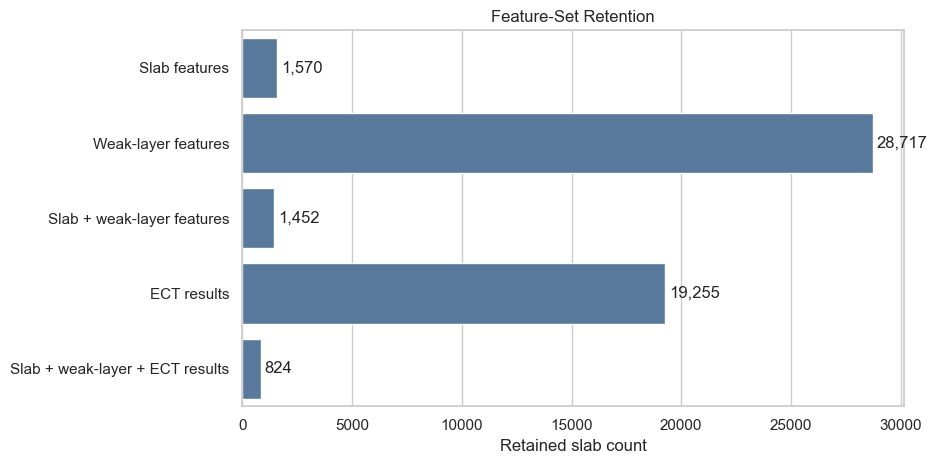

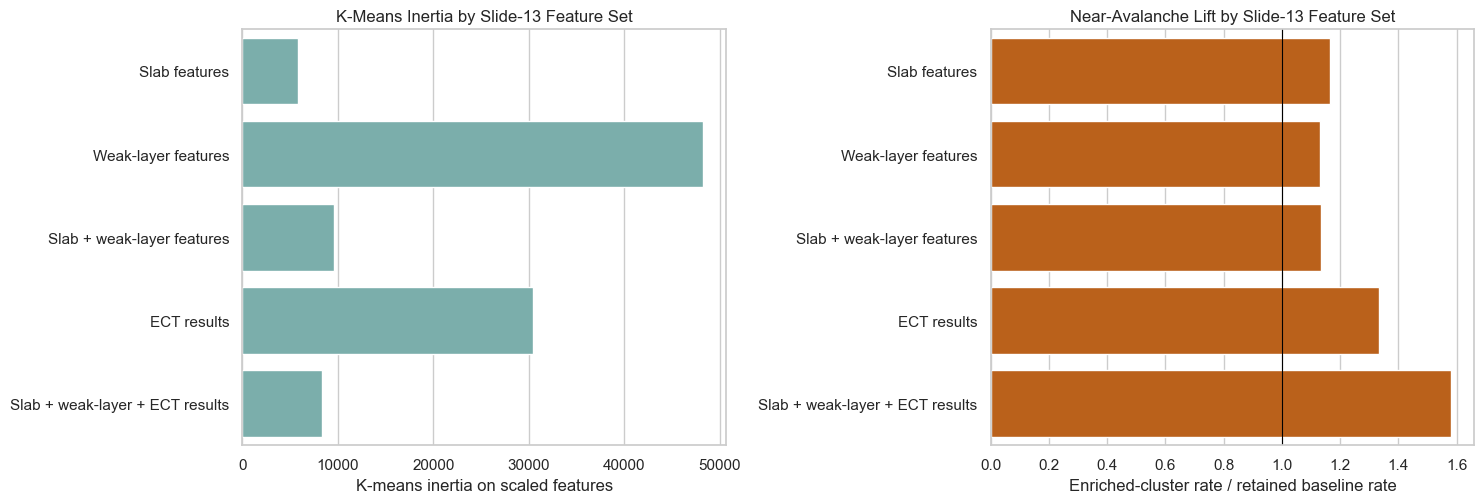

In [9]:
plot_summary_df = feature_set_summary_df.copy()
plot_summary_df["display_name"] = pd.Categorical(
    plot_summary_df["display_name"],
    categories=[FEATURE_SET_DISPLAY_NAMES[name] for name in FEATURE_SET_NAMES],
    ordered=True,
)

fig, retention_ax = plt.subplots(figsize=(9.5, 4.8))
sns.barplot(
    data=plot_summary_df,
    x="total_slabs_retained",
    y="display_name",
    color="#4C78A8",
    ax=retention_ax,
)
retention_ax.set_title("Feature-Set Retention")
retention_ax.set_xlabel("Retained slab count")
retention_ax.set_ylabel("")
for container in retention_ax.containers:
    retention_ax.bar_label(container, labels=[f"{value:,.0f}" for value in plot_summary_df["total_slabs_retained"]], padding=3)
fig.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
sns.barplot(
    data=plot_summary_df,
    x="kmeans_inertia",
    y="display_name",
    color="#72B7B2",
    ax=axes[0],
)
axes[0].set_title("K-Means Inertia by Slide-13 Feature Set")
axes[0].set_xlabel("K-means inertia on scaled features")
axes[0].set_ylabel("")

sns.barplot(
    data=plot_summary_df,
    x="enriched_cluster_rate_lift",
    y="display_name",
    color="#D55E00",
    ax=axes[1],
)
axes[1].axvline(1, color="black", linewidth=0.8)
axes[1].set_title("Near-Avalanche Lift by Slide-13 Feature Set")
axes[1].set_xlabel("Enriched-cluster rate / retained baseline rate")
axes[1].set_ylabel("")
fig.tight_layout()

## Appendix: Presentation Content

## Background on K-Means Clustering
- K-means is an unsupervised clustering algorithm that partitions observations into a specified number of groups based on feature similarity.
- For this analysis, each slab is represented by one slide-13 feature set, features are standardized, and K-means is run with K=2 for a consistent presentation comparison.
- The algorithm assigns slabs to clusters by minimizing within-cluster distance to each cluster centroid; avalanche context is not used as an input.
- Important considerations: K must be chosen ahead of time, results depend on feature scaling and feature selection, and clusters should not be interpreted as validated classes without external labels.
- K-means inertia measures the within-cluster sum of squared distances on scaled features. Lower values indicate more compact clusters for the retained sample and selected feature space.
- In this presentation, inertia is used as a feature-space compactness diagnostic, not as a direct measure of avalanche prediction performance.

## Description of dataset
- Source data: SnowPylot CAAML files from `snowpits/2015_2025`.
- Parsed dataset size: 50,278 SnowPylot pits, all converted into SnowPyt-MechParams pit objects.
- Usable analysis units: 34,690 slabs created from the layer of concern.
- Avalanche-context label: 1,381 slabs are marked as near an avalanche; 33,309 slabs have unknown or unrecorded avalanche context.
- Interpretation of labels: near-avalanche slabs are treated as known unstable examples, while unlabeled slabs are treated as unknown context rather than stable negatives.
- Feature families available for clustering match slide 13: slab features, weak-layer features, slab plus weak-layer features, ECT results, and slab/weak-layer/ECT results.
- Feature coverage varies substantially: weak-layer variables are broadly available, ECT features have moderate coverage, and D11 bending stiffness has very low coverage.

## Idea
- Pits marked as near an avalanche likely represent a subset of slabs with unstable characteristics.
- The analysis asks whether any slide-13 feature set forms two compact K-means clusters where one cluster is enriched in these known near-avalanche examples.
- A useful feature set would ideally produce both compact feature-space clusters and meaningful near-avalanche enrichment after clustering.
- Cluster compactness is summarized with K-means inertia, the within-cluster sum of squared distances on scaled features; lower is better within a retained sample and feature space.
- Near-avalanche enrichment is summarized with the in-sample near-avalanche rate in the enriched cluster, bootstrap intervals, permutation p-values, lift relative to the retained baseline rate, and the share of near-avalanche slabs captured by that cluster.
- The enriched cluster should be described as a near-avalanche enriched cluster, not as a confirmed instability class, because unlabeled slabs are not confirmed stable examples.
- The results should be framed as exploratory in-sample feature-set diagnostics rather than a validated operational stability classifier.

## Analysis outline
- Parse CAAML pits using SnowPylot utilities and convert parsed pits into SnowPyt-MechParams pit objects.
- Create slabs from the layer of concern and keep pit/slab identifiers plus avalanche-context metadata for post-clustering diagnostics.
- Engineer slab-level features: slab thickness, slab weight, layer count, cumulative hand-hardness index, mean slab hand hardness, and D11 bending stiffness.
- Engineer weak-layer features: weak-layer thickness, weak-layer hand-hardness index, and persistent grain-form indicator.
- Parse ECT results into numeric summaries: propagation rate, mean taps, instability index, and whether any propagating result was observed.
- Define the five slide-13 feature sets: slab features, weak-layer features, slab plus weak-layer features, ECT results, and slab/weak-layer/ECT results.
- Filter each feature set to complete cases, standardize selected features, and apply K-means with K=2.
- Use natural retained samples so the presentation can compare both clustering diagnostics and the coverage cost of each feature family.
- Assign the near-avalanche enriched cluster after clustering by selecting the cluster with the higher in-sample near-avalanche rate.
- Report permutation p-values and bootstrap confidence intervals as exploratory enrichment diagnostics.

## Results, Challenges, Sources, and AI Disclosure
- Dataset snapshot table: 50,278 parsed pits, 34,690 usable slabs, 1,381 slabs marked near avalanche, and 33,309 slabs with unknown/unrecorded avalanche context.
- Feature coverage table or chart: weak-layer variables have high coverage, ECT features have moderate coverage, and D11 bending stiffness has very low coverage.
- Slide 14 results table should report one row per slide-13 feature set: number of features, slabs retained, near-avalanche slabs retained, cluster sizes, K-means inertia, enriched-cluster near-avalanche rate, lift, and capture share.
- Slide 15 PCA plots should show the feature set with lowest inertia and the feature set with strongest near-avalanche lift.
- Interpretation should identify which slide-13 feature set has the lowest inertia, which has the strongest near-avalanche enrichment, and how missing data affects the comparison.
- Challenges: many source variables are qualitative, ECT strings require parsing, D11 has very low coverage, near-avalanche labels are sparse and one-sided, and K-means assumes compact roughly spherical feature-space clusters.
- Sources: Snow Pilot/SnowPylot data and documentation, SnowPyt-MechParams calculations, and K-means background references listed in the presentation.
- AI disclosure: AI assistance was used to help structure notebook narrative, organize slide-support outputs, and review wording; analytical calculations come from the executed notebook code and SnowPylot/SnowPyt-MechParams data objects.

,feature_set,display_name,selection_reason,selection_metric,kmeans_inertia,enriched_cluster_rate_lift,enriched_cluster_near_avalanche_rate,total_slabs_retained,near_avalanche_slabs_retained
0,slab_weak_layer_ect_results,Slab + weak-layer + ECT results,Highest enriched-cluster lift,enriched_cluster_rate_lift,"8,377.433",1.581,7.289,824,38
1,slab_features,Slab features,Lowest inertia,kmeans_inertia,"5,780.384",1.167,5.574,1570,75


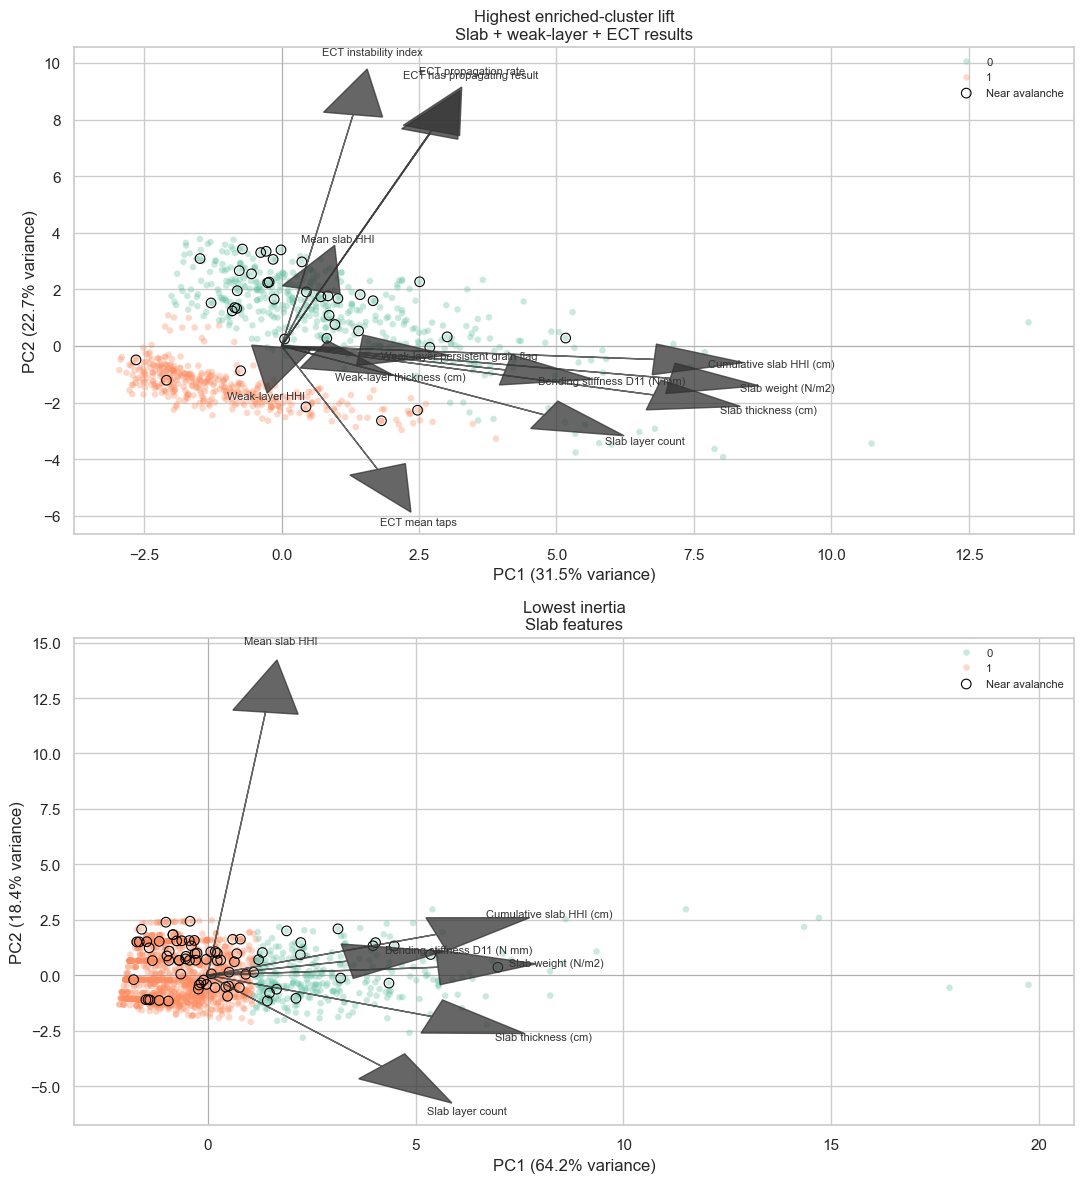

In [10]:
def pca_selection_rows(summary_df):
    """Select slide-13 feature sets with the strongest compactness and enrichment diagnostics."""
    selection_records = []
    selection_specs = [
        ("Lowest inertia", "kmeans_inertia"),
        ("Highest enriched-cluster lift", "enriched_cluster_rate_lift"),
    ]

    for selection_reason, metric_column in selection_specs:
        if metric_column == "kmeans_inertia":
            selected_row = summary_df.loc[summary_df[metric_column].idxmin()].copy()
        else:
            selected_row = summary_df.loc[summary_df[metric_column].idxmax()].copy()
        selected_row["selection_reason"] = selection_reason
        selected_row["selection_metric"] = metric_column
        selection_records.append(selected_row)

    selection_df = pd.DataFrame(selection_records)
    selection_df = (
        selection_df.groupby(["feature_set", "display_name"], as_index=False)
        .agg(
            selection_reason=("selection_reason", ", ".join),
            selection_metric=("selection_metric", ", ".join),
            kmeans_inertia=("kmeans_inertia", "first"),
            enriched_cluster_rate_lift=("enriched_cluster_rate_lift", "first"),
            enriched_cluster_near_avalanche_rate=(
                "enriched_cluster_near_avalanche_rate",
                "first",
            ),
            total_slabs_retained=("total_slabs_retained", "first"),
            near_avalanche_slabs_retained=("near_avalanche_slabs_retained", "first"),
        )
        .sort_values("selection_reason", kind="mergesort")
        .reset_index(drop=True)
    )
    return selection_df


def pca_input_for_selection(selection_row):
    """Recreate the scaled feature matrix and metadata for a selected feature set."""
    feature_set_name = selection_row["feature_set"]
    feature_columns = FEATURE_SET_DEFINITIONS[feature_set_name]
    analysis_mask = complete_case_mask(slab_features_df, feature_columns)
    selected_columns = list(ANALYSIS_METADATA_COLUMNS) + feature_columns + [CLUSTER_ORDER_COLUMN]
    selected_columns = list(dict.fromkeys(selected_columns))
    analysis_df = slab_features_df.loc[analysis_mask, selected_columns].reset_index(drop=True)

    clustered_slabs_df = feature_set_results[feature_set_name]["clustered_slabs"].reset_index(drop=True)
    assert analysis_df["pit_id"].equals(clustered_slabs_df["pit_id"])
    assert analysis_df["slab_id"].equals(clustered_slabs_df["slab_id"])

    feature_scaler = StandardScaler()
    scaled_feature_values = feature_scaler.fit_transform(
        analysis_df[feature_columns].astype(float)
    )
    pca_model = PCA(n_components=2)
    pca_scores = pca_model.fit_transform(scaled_feature_values)

    pca_scores_df = analysis_df[ANALYSIS_METADATA_COLUMNS + [CLUSTER_ORDER_COLUMN]].copy()
    pca_scores_df["feature_set"] = feature_set_name
    pca_scores_df["display_name"] = FEATURE_SET_DISPLAY_NAMES[feature_set_name]
    pca_scores_df["cluster"] = clustered_slabs_df["cluster"].to_numpy()
    pca_scores_df["PC1"] = pca_scores[:, 0]
    pca_scores_df["PC2"] = pca_scores[:, 1]

    loadings_df = pd.DataFrame(
        pca_model.components_.T,
        columns=["PC1", "PC2"],
        index=feature_columns,
    ).reset_index(names="feature")
    loadings_df["display_name"] = loadings_df["feature"].map(FEATURE_DISPLAY_NAMES).fillna(
        loadings_df["feature"]
    )

    return pca_scores_df, loadings_df, pca_model


def plot_pca_biplot(selection_row, axis):
    """Plot PCA scores, cluster labels, near-avalanche highlights, and feature loadings."""
    pca_scores_df, loadings_df, pca_model = pca_input_for_selection(selection_row)
    cluster_palette = dict(
        zip(
            sorted(pca_scores_df["cluster"].unique()),
            sns.color_palette("Set2", n_colors=pca_scores_df["cluster"].nunique()),
        )
    )

    sns.scatterplot(
        data=pca_scores_df,
        x="PC1",
        y="PC2",
        hue="cluster",
        palette=cluster_palette,
        alpha=0.35,
        linewidth=0,
        s=22,
        ax=axis,
    )

    near_avalanche_df = pca_scores_df[pca_scores_df["near_avalanche_flag"]]
    axis.scatter(
        near_avalanche_df["PC1"],
        near_avalanche_df["PC2"],
        facecolors="none",
        edgecolors="black",
        linewidths=0.8,
        s=48,
        label="Near avalanche",
        zorder=4,
    )

    score_extent = max(
        pca_scores_df["PC1"].abs().max(),
        pca_scores_df["PC2"].abs().max(),
    )
    loading_extent = max(
        loadings_df["PC1"].abs().max(),
        loadings_df["PC2"].abs().max(),
    )
    loading_scale = 0.72 * score_extent / loading_extent if loading_extent else 1.0

    for _, loading_row in loadings_df.iterrows():
        x_loading = loading_row["PC1"] * loading_scale
        y_loading = loading_row["PC2"] * loading_scale
        axis.arrow(
            0,
            0,
            x_loading,
            y_loading,
            color="#333333",
            alpha=0.75,
            width=0.0,
            head_width=0.08 * score_extent,
            length_includes_head=True,
            zorder=5,
        )
        axis.text(
            x_loading * 1.06,
            y_loading * 1.06,
            loading_row["display_name"],
            fontsize=8,
            color="#333333",
            ha="center",
            va="center",
            zorder=6,
        )

    explained_variance = pca_model.explained_variance_ratio_ * 100
    axis.axhline(0, color="#888888", linewidth=0.6, alpha=0.5)
    axis.axvline(0, color="#888888", linewidth=0.6, alpha=0.5)
    axis.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)")
    axis.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)")
    axis.set_title(
        f"{selection_row['selection_reason']}\n"
        f"{selection_row['display_name']}"
    )
    axis.legend(frameon=False, loc="best", fontsize=8)


pca_selected_feature_sets_df = pca_selection_rows(feature_set_summary_df)
display(pca_selected_feature_sets_df)

fig, axes = plt.subplots(
    len(pca_selected_feature_sets_df),
    1,
    figsize=(11, 6 * len(pca_selected_feature_sets_df)),
    squeeze=False,
)
for axis, (_, selection_row) in zip(axes.ravel(), pca_selected_feature_sets_df.iterrows()):
    plot_pca_biplot(selection_row, axis)

fig.tight_layout()